<img src="./logo_UNSAM.png" align="right" width="150" /> 

# Trabajo Semanal Nº3

#### Nicolás Galván

# Introducción

En esta experiencia se estudió el comportamiento espectral de señales senoidales mediante la Transformada Discreta de Fourier (DFT), con especial énfasis en el fenómeno de desparramo espectral o spectral leakage.

El objetivo principal fue analizar cómo pequeñas variaciones en la frecuencia de una señal respecto de la resolución espectral afectan su representación en la densidad espectral de potencia (PSD). Para ello, se trabajó con señales senoidales de potencia normalizada y se evaluó su comportamiento bajo distintas condiciones de desintonía.

Además, se verificó la conservación de energía mediante la identidad de Parseval y se estudió el efecto de aplicar la técnica de zero-padding, con el fin de observar su influencia sobre la visualización espectral.

A través de simulaciones numéricas y análisis de resultados, se buscó relacionar los fundamentos teóricos del análisis espectral discreto con su interpretación práctica en procesamiento digital de señales.

## Ejercicio Nº1

### a)

Llamo a las librerías a utilizar.

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft

Defino mi función seno.

In [45]:
def sen(ff, nn, vmax=1, dc=0, ph=0, fs=2):
    n = np.arange(0, nn)
    tt = n/fs
    w0 = 2 * np.pi * ff
    xx = dc + vmax * np.sin(w0 * tt + ph)
    return tt, xx

Defino mis variables a implementar.

In [46]:
N = 1000
Fs = N
df = Fs/N
vmx= np.sqrt(2)
# Defino las tres frecuencias pedidas
f1 = (N/4) * df
f2 = (N/4 + 0.25) * df
f3 = (N/4 + 0.5) * df

Generación de señales.

In [47]:
_, x1 = sen(ff=f1, nn=N, vmax= vmx,fs=Fs)
_, x2 = sen(ff=f2, nn=N, vmax= vmx, fs=Fs)
_, x3 = sen(ff=f3, nn=N, vmax= vmx, fs=Fs)

Cálculo las FFTs.

In [48]:
X1 = fft(x1)
X2 = fft(x2)
X3 = fft(x3)

Cálculo las PSDs.

In [49]:
PSD1 = (np.abs(X1)/N)**2
PSD2 = (np.abs(X2)/N)**2
PSD3 = (np.abs(X3)/N)**2

Defino mi eje frecuencial.

In [50]:
frec = np.arange(N) * df

Me quedo con la mitad positiva.

In [51]:
frec_half = frec[:N//2 + 1]

Cálculo las PSDs unilaterales.

In [52]:
PSD1_uni = PSD1[:N//2 + 1].copy()
PSD1_uni*= 2

PSD2_uni = PSD2[:N//2 + 1].copy()
PSD2_uni *= 2


PSD3_uni = PSD3[:N//2 + 1].copy()
PSD3_uni *= 2

Las paso a dB.

In [53]:
PSD1_uni_db = 10 * np.log10(PSD1_uni + 1e-20)


PSD2_uni_db = 10 * np.log10(PSD2_uni + 1e-20)


PSD3_uni_db = 10 * np.log10(PSD3_uni + 1e-20)

Se grafica las PSDs.

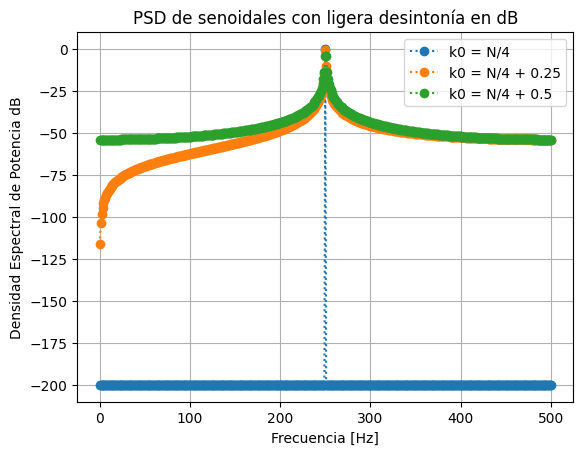

In [54]:
plt.figure()
plt.plot(frec_half, PSD1_uni_db,':o', label="k0 = N/4")
plt.plot(frec_half, PSD2_uni_db,':o',label="k0 = N/4 + 0.25")
plt.plot(frec_half, PSD3_uni_db,':o', label="k0 = N/4 + 0.5")

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad Espectral de Potencia dB")
plt.title("PSD de senoidales con ligera desintonía en dB")
plt.legend()
plt.grid(True)
plt.show()


### b)

Verificación del teorema de Parseval.

In [55]:
Et1 = np.sum(np.abs(x1)**2)
Ef1 = (1/N)*np.sum(np.abs(X1)**2)

Et2 = np.sum(np.abs(x2)**2)
Ef2 = (1/N)*np.sum(np.abs(X2)**2)

Et3 = np.sum(np.abs(x3)**2)
Ef3 = (1/N)*np.sum(np.abs(X3)**2)

Verificación de la potencia unitaria de cada PSD.

In [56]:
P1 = np.sum(np.abs(x1)**2)/N 
P2 = np.sum(np.abs(x2)**2)/N
P3 = np.sum(np.abs(x3)**2)/N

In [57]:
print("Verificación de Parseval y la potencia unitaria:")
print("Potencia desde PSD:")
print(f" Señal k0=N/4      -> P = {P1:.5f}")
print(f" Señal k0=N/4+0.25 -> P = {P2:.5f}")
print(f" Señal k0=N/4+0.5  -> P = {P3:.5f}")

print("\nLa diferencia entre la energia en el dominio del tiempo y la energia en el dominio de la frecuencia")
print(f" Señal k0=N/4      -> diferencia = {Et1 - Ef1:.5e}")
print(f" Señal k0=N/4+0.25 -> diferencia = {Et2 - Ef2:.5e}")
print(f" Señal k0=N/4+0.5  -> diferencia = {Et3 - Ef3:.5e}")

Verificación de Parseval y la potencia unitaria:
Potencia desde PSD:
 Señal k0=N/4      -> P = 1.00000
 Señal k0=N/4+0.25 -> P = 0.99900
 Señal k0=N/4+0.5  -> P = 1.00000

La diferencia entre la energia en el dominio del tiempo y la energia en el dominio de la frecuencia
 Señal k0=N/4      -> diferencia = 1.13687e-13
 Señal k0=N/4+0.25 -> diferencia = 2.27374e-13
 Señal k0=N/4+0.5  -> diferencia = -2.27374e-13


### c)

Defino mi factor de padding

In [58]:
CantNP = 9

Defino mi nuevo tamaño. 

In [59]:
Npad = CantNP* N

Le agrego los ceros. 

In [60]:
x3_pad = np.concatenate((x3, np.zeros(Npad - N)))
x2_pad = np.concatenate((x2, np.zeros(Npad - N)))
x1_pad = np.concatenate((x1, np.zeros(Npad - N)))

Cálculo las FFTs con padding.

In [61]:
X3z = fft(x3_pad)
X2z = fft(x2_pad)
X1z = fft(x1_pad)

Defino mi nuevo eje frecuencial.

In [62]:
frec_pad = np.arange(Npad) * Fs / Npad

Me quedo con la mitad positiva.

In [63]:
frec_pad_half = frec_pad[:Npad//2 + 1]

Cálculo las PSDs con padding.

In [64]:
PSD1z = (np.abs(X1z) / N)**2
PSD1z_uni = PSD1z[:Npad//2 + 1].copy()
PSD1z_uni[1:-1] *= 2

PSD2z = (np.abs(X2z) / N)**2
PSD2z_uni = PSD2z[:Npad//2 + 1].copy()
PSD2z_uni[1:-1] *= 2

PSD3z = (np.abs(X3z) / N)**2
PSD3z_uni = PSD3z[:Npad//2 + 1].copy()
PSD3z_uni[1:-1] *= 2


Las paso a dB.

In [65]:
PSD1z_uni_db = 10 * np.log10(PSD1z_uni + 1e-20)

PSD2z_uni_db = 10 * np.log10(PSD2z_uni + 1e-20)

PSD3z_uni_db = 10 * np.log10(PSD3z_uni + 1e-20)


Se grafica las PSDs.

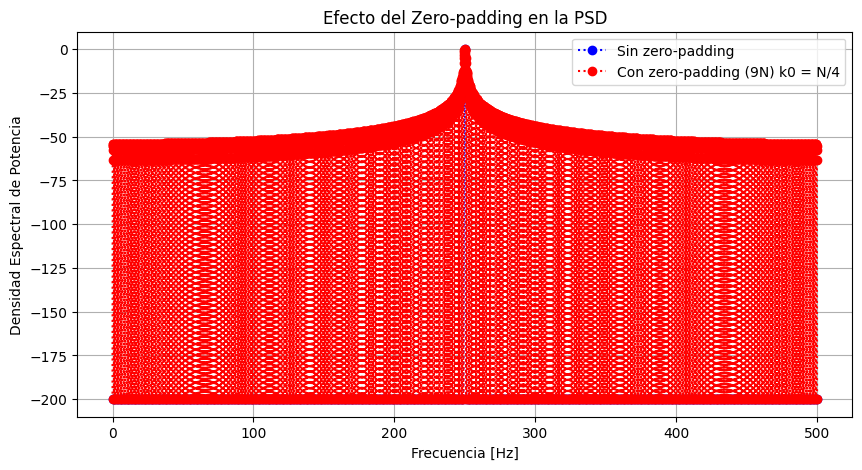

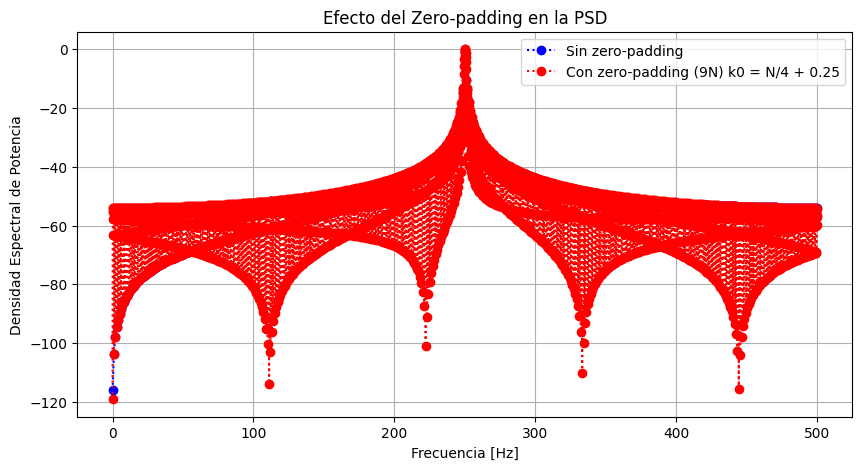

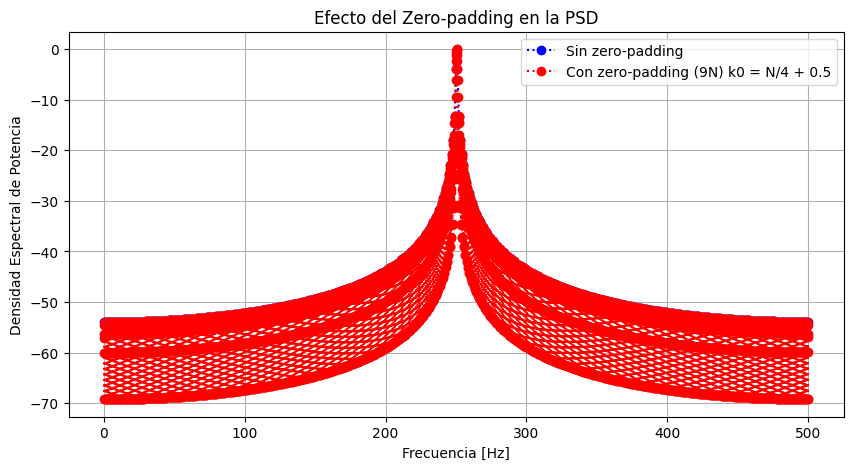

In [66]:
plt.figure(figsize=(10,5))
plt.plot(frec_half, PSD1_uni_db, ':o',color ='blue',label="Sin zero-padding")
plt.plot(frec_pad_half, PSD1z_uni_db, ':o',color ='Red', label=f"Con zero-padding ({CantNP}N) k0 = N/4")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad Espectral de Potencia")
plt.title("Efecto del Zero-padding en la PSD")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(frec_half, PSD2_uni_db, ':o',color ='blue',label="Sin zero-padding")
plt.plot(frec_pad_half, PSD2z_uni_db, ':o',color ='Red', label=f"Con zero-padding ({CantNP}N) k0 = N/4 + 0.25")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad Espectral de Potencia")
plt.title("Efecto del Zero-padding en la PSD")
plt.legend()
plt.grid(True)

plt.figure(figsize=(10,5))
plt.plot(frec_half, PSD3_uni_db, ':o',color ='blue',label="Sin zero-padding")
plt.plot(frec_pad_half, PSD3z_uni_db, ':o',color ='Red', label=f"Con zero-padding ({CantNP}N) k0 = N/4 + 0.5")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad Espectral de Potencia")
plt.title("Efecto del Zero-padding en la PSD")
plt.legend()
plt.grid(True)

# Análisis de resultados 

En esta experiencia se estudió el efecto del desparramo espectral en la DFT mediante el análisis de señales senoidales de potencia normalizada, evaluando además la verificación de potencia mediante la identidad de Parseval y el efecto de aplicar la técnica de zero-padding.

Se trabajó con tres señales cuyas frecuencias fueron:

- $k_0 = \frac{N}{4}$
- $k_0 = \frac{N}{4} + 0.25$
- $k_0 = \frac{N}{4} + 0.5$

Posteriormente se repitió el análisis agregando un vector de longitud $9N$ compuesto por ceros al final de cada señal.

---

## Ítem a) Efecto de la desintonía en la PSD

### Caso 1: $k_0 = \frac{N}{4}$

La frecuencia coincide exactamente con un bin de la DFT.

La energía se concentra en una única línea espectral, observándose un pico definido y ausencia de dispersión significativa.

No aparece desparramo espectral.

---

### Caso 2: $k_0 = \frac{N}{4} + 0.25$

Existe una desintonía de un cuarto de bin.

La energía comienza a distribuirse entre bins vecinos, generando lóbulos laterales y ensanchamiento del pico principal.

Se evidencia desparramo espectral moderado.

---

### Caso 3: $k_0 = \frac{N}{4} + 0.5$

La señal presenta media separación entre bins.

La energía se reparte de forma casi simétrica entre bins cercanos, produciendo máxima dispersión.

Este es el caso donde el desparramo espectral resulta más evidente.

---

### Discusión

La DFT evalúa frecuencias discretas separadas según:

$$
\Delta f = \frac{f_s}{N}
$$

Cuando la frecuencia de la señal coincide exactamente con uno de esos valores, la energía se concentra.

Cuando no coincide, debe repartirse entre múltiples bins.

Esto explica por qué pequeñas diferencias frecuenciales generan espectros muy distintos.

---

## Ítem b) Verificación de potencia unitaria

Se verificó la potencia mediante la identidad de Parseval:

$$
\sum_{n=0}^{N-1}|x[n]|^2 = \frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2
$$

Los resultados obtenidos fueron:

| Señal | Potencia |
|------|---------|
| $k_0 = N/4$ | 1.00000 |
| $k_0 = N/4 + 0.25$ | 0.99900 |
| $k_0 = N/4 + 0.5$ | 1.00000 |

Las diferencias entre energía temporal y frecuencial fueron del orden de:

$$
10^{-13}
$$

---
### Discusión de los resultados obtenidos

La potencia unitaria de cada PSD fue verificada calculando la potencia promedio temporal de las señales y corroborando el cumplimiento de la identidad de Parseval. Los valores obtenidos resultaron prácticamente iguales a 1, mientras que la diferencia entre energía temporal y frecuencial fue del orden de $10^{-13}$, confirmando la correcta conservación de energía.

Respecto a las diferencias espectrales observadas entre señales separadas por muy pocos Hertz, estas se deben al fenómeno de desparramo espectral. Aunque la diferencia absoluta de frecuencia sea pequeña, la DFT sólo evalúa componentes en frecuencias discretas separadas por $\Delta f$.

Cuando una señal coincide exactamente con un bin, su energía se concentra en una única línea espectral. En cambio, cuando existe desintonía, la energía debe distribuirse entre bins vecinos, generando dispersión espectral.

Por esta razón, señales muy cercanas en frecuencia pueden presentar espectros notablemente distintos.

---

## Ítem c) Efecto del zero-padding

Para este apartado se aplicó zero-padding agregando:

$$
9N
$$

ceros al final de cada señal.

Esto genera una nueva longitud:

$$
N_{pad}=9N
$$

La nueva resolución espectral aparente pasa a ser:

$$
\Delta f_{pad} = \frac{f_s}{9N}
$$

---

### Resultados observados

#### Caso 1: $k_0 = \frac{N}{4}$

El espectro continúa mostrando un pico perfectamente localizado.

Sin embargo, ahora aparece una representación mucho más suave y detallada de la forma espectral.

Se observa con mayor precisión la estructura del lóbulo principal.

---

#### Caso 2: $k_0 = \frac{N}{4}+0.25$

El zero-padding permite visualizar con mucha mayor claridad el desparramo espectral.

La forma sinc del espectro se vuelve evidente.

Se distinguen mejor:

- El lóbulo principal
- Los lóbulos secundarios
- Los mínimos espectrales

---

#### Caso 3: $k_0 = \frac{N}{4}+0.5$

El efecto es aún más notorio.

La distribución simétrica de energía entre bins puede apreciarse con mayor detalle.

La interpolación espectral permite visualizar con claridad la envolvente completa.

---

### Discusión de los resultados obtenidos

El zero-padding no modifica la información espectral real de la señal.

No mejora la resolución espectral real ni elimina el desparramo.

Lo que hace es aumentar artificialmente la cantidad de muestras del espectro calculado.

Esto produce una interpolación más densa entre los bins originales.

En consecuencia:

#### Lo que se mejora es:

- La visualización del espectro
- La localización aparente del pico
- La observación de lóbulos laterales
- La interpretación gráfica del desparramo espectral

#### Lo que no se mejora es:

- La capacidad real de distinguir frecuencias cercanas
- La resolución espectral real
- La eliminación del desparramo espectral

---

### Interpretación física

El zero-padding equivale a calcular más puntos de la transformada de Fourier continua de la misma ventana temporal.

No agrega nueva información porque no incorpora nuevas muestras reales de la señal.

Simplemente realiza una interpolación espectral.

---

# Autoevaluación del aprendizaje y conclusiones obtenidas

## Autoevaluación del aprendizaje

El desarrollo de esta experiencia permitió afianzar conceptos fundamentales vinculados al análisis espectral discreto y a la implementación práctica de la DFT mediante herramientas computacionales.

A lo largo de la actividad se logró comprender de manera más concreta la relación entre los fundamentos teóricos y su manifestación práctica en el procesamiento digital de señales.

En particular, se consolidaron los siguientes aprendizajes:

### Comprensión del desparramo espectral

Se pudo observar experimentalmente cómo pequeñas desintonías entre la frecuencia de una señal y la grilla espectral de la DFT generan redistribución de energía entre múltiples bins.

Esto permitió interpretar con claridad el fenómeno de desparramo espectral, comprendiendo que no se trata de una pérdida de energía, sino de una dispersión provocada por el truncamiento temporal y la discretización frecuencial.

---

### Interpretación de la resolución espectral

Se comprendió la importancia de la relación:

$$
\Delta f = \frac{f_s}{N}
$$

como parámetro que determina la separación entre bins y condiciona la representación espectral de una señal.

Se verificó que la correcta alineación entre frecuencia de entrada y bins de la DFT resulta determinante para obtener una representación espectral concentrada.

---

### Aplicación de la identidad de Parseval

La verificación numérica permitió comprobar la conservación de energía entre dominio temporal y frecuencial.

Esto fortaleció la comprensión del vínculo matemático entre ambas representaciones y permitió validar experimentalmente la correcta implementación computacional del cálculo espectral.

---

### Comprensión del zero-padding

Se adquirió una interpretación más precisa sobre el uso del zero-padding.

Inicialmente puede interpretarse como una mejora en resolución, pero el análisis permitió comprender que su verdadero efecto consiste en una interpolación espectral que mejora la visualización sin agregar nueva información.

---

## Conclusiones obtenidas

A partir de los resultados obtenidos, pueden extraerse las siguientes conclusiones:

### 1. La DFT es altamente sensible a la alineación frecuencial

La coincidencia exacta entre la frecuencia de una señal y un bin de la DFT permite una representación espectral ideal.

Desintonías incluso pequeñas generan desparramo espectral significativo.

---

### 2. El desparramo espectral redistribuye energía, pero no la modifica

La energía total permanece constante.

Lo que cambia es únicamente su distribución entre componentes espectrales.

Esto fue verificado mediante la identidad de Parseval.

---

### 3. El zero-padding mejora la visualización, no la resolución real

Permite observar con mayor detalle la estructura espectral y facilita el análisis gráfico, pero no incrementa la capacidad física de distinguir frecuencias cercanas.

---

## Reflexión final

La actividad resultó valiosa para consolidar la comprensión práctica del análisis espectral discreto.

Permitió vincular teoría, simulación e interpretación de resultados, fortaleciendo criterios de análisis que serán fundamentales para estudios posteriores relacionados con procesamiento digital de señales, análisis frecuencial y diseño de sistemas digitales.